<a href="https://colab.research.google.com/github/so-rn/Finance-app/blob/main/Migros_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## First Project - **MIGROS**

In [ ]:
!pip install osmnx geopandas folium statsmodels seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 3.4 MB/s eta 0:00:00


In [ ]:
# Import Library
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import folium

# Set plot style for presentation visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

In [ ]:
# DATA LOADING & PRE-PROCESSING (Data Cleaning)
print("Loading and cleaning socio-economic and store datasets...")

# 1.1 Load supermarket data extracted from OpenStreetMap
df_stores = pd.read_csv('geneva_supermarkets_data_with_address.csv')
stores_gdf = gpd.GeoDataFrame(
    df_stores,
    geometry=gpd.points_from_xy(df_stores.longitude, df_stores.latitude),
    crs="EPSG:4326"
)
df_stores.head()

Loading and cleaning socio-economic and store datasets...


,name,brand_category,operator,shop,latitude,longitude,addr:housenumber,addr:street,addr:postcode,addr:city
0,Coop,Coop,NaN,supermarket,46.169006,6.121073,2,Chem. de Vers,1228.0,Plan-les-Ouates
1,Migros,Migros,NaN,supermarket,46.192060,6.164144,86,Route de Florissant,NaN,Genève
2,COOP,Coop,NaN,supermarket,46.193306,6.161276,56,Route de Florissant,1206.0,Genève
3,Migros,Migros,NaN,supermarket,46.190858,6.152480,NaN,NaN,1206.0,NaN
4,Migros,Migros,Société Coopérative Migros Genève,supermarket,46.232767,6.112525,NaN,NaN,NaN,NaN


In [ ]:
# Load official population data from Federal Statistical Office (FSO)
df_pop = pd.read_csv('OCS_POPBATLOG_COMMUNE.csv', sep=';')
df_pop['COMMUNE'] = df_pop['COMMUNE'].str.strip()  # Remove accidental trailing spaces
df_pop.head()

,OBJECTID,DATE_REF,NO_COMMUNE,COMMUNE,BAT_TOTAL,BAT_SANS_LOG,BATLOG_TOT,MAISON_INDIV,BAT_LOG_1_2,BAT_LOG_3_9,...,POPULATION,POP_HOMMES,POP_FEMMES,POP_CH,POP_ETR,AGE_0_19,AGE_20_64,AGE_65_PLUS,SHAPE.AREA,SHAPE.LEN
0,1,12-2025,6624,Gy,265,121,144,96,123,20,...,582,266,316,467,115,137,339,106,3.286289e+06,15240.281691
1,2,12-2025,6631,Onex,2107,795,1312,829,895,164,...,19141,9157,9984,11985,7156,4071,11385,3685,2.813933e+06,8800.054395
2,3,12-2025,6641,Troinex,1309,612,697,522,587,96,...,3365,1667,1698,2573,792,772,2047,546,3.429908e+06,9160.554904
3,20,12-2025,6639,Soral,346,149,197,120,158,37,...,934,436,498,754,180,212,513,209,2.942051e+06,12467.455094
4,21,12-2025,6627,Laconnex,395,189,206,166,196,7,...,713,358,355,610,103,149,401,163,3.831199e+06,9049.018702


In [ ]:
# Load purchasing power proxy and filter for the most recent year (2022)
df_power = pd.read_csv('geneva_purchasing_power_proxy_all_years.csv')
df_power_2022 = df_power[df_power['year'] == 2022].copy()
df_power_2022['commune'] = df_power_2022['commune'].str.strip()
df_power.head()

,year,commune,geography_level,proxy_purchasing_power_median_chf,proxy_index_canton_100,proxy_rank_within_year,all_persons_assujetties,all_q1_chf,all_median_chf,all_q3_chf,...,single_q1_chf,single_median_chf,single_q3_chf,single_q3_q1_ratio,married_persons_assujetties,married_q1_chf,married_median_chf,married_q3_chf,married_q3_q1_ratio,canton_median_chf
0,2014,Canton,canton,59185.00,100.000000,NaN,310208,35313.00,59185.00,93656.0,...,26471.0,52023.5,86761.0,3.277587,150168,42502.75,65122.25,101933.50,2.398280,59185.0
1,2014,Vandoeuvres,commune,93289.50,157.623553,1.0,1769,42609.00,93289.50,205378.5,...,3701.0,45293.0,105307.0,28.453661,1008,72274.50,142530.50,297130.00,4.111132,59185.0
2,2014,Avusy,commune,87582.25,147.980485,2.0,1044,45067.75,87582.25,131921.0,...,15400.5,55726.0,107635.5,6.989091,620,69458.00,101090.50,142510.50,2.051751,59185.0
3,2014,Cologny,commune,87015.00,147.022050,3.0,3452,44344.00,87015.00,169797.0,...,11341.0,61770.5,111505.5,9.832069,1900,64199.00,111992.25,221123.00,3.444337,59185.0
4,2014,Choulex,commune,86205.00,145.653459,4.0,767,47491.00,86205.00,142453.5,...,16009.0,59801.0,117748.0,7.355113,384,68241.50,104701.25,168103.25,2.463358,59185.0


In [ ]:
# GEOSPATIAL BOUNDARIES FETCHING & SPATIAL JOIN

print("Fetching administrative commune boundaries for Geneva via OSMnx...")
# Fetch official municipality boundaries (admin_level=8 corresponds to Communes in Switzerland)
geneva_boundaries = ox.features_from_place("Canton of Geneva, Switzerland", tags={'admin_level': '8'})
geneva_boundaries = geneva_boundaries[geneva_boundaries.geometry.type.isin(['Polygon', 'MultiPolygon'])].reset_index()
geneva_boundaries = geneva_boundaries[['name', 'geometry']].rename(columns={'name': 'COMMUNE_NAME'})
geneva_boundaries = geneva_boundaries.to_crs(epsg=4326)

print("Overlaying stores onto boundaries using Spatial Join...")
# Perform a Spatial Join to perfectly assign each store to its true geographical commune boundary
joined_stores = gpd.sjoin(stores_gdf, geneva_boundaries, how="inner", predicate="intersects")
store_counts = joined_stores.groupby('COMMUNE_NAME').size().reset_index(name='STORE_COUNT')

Fetching administrative commune boundaries for Geneva via OSMnx...
Overlaying stores onto boundaries using Spatial Join...


In [ ]:
# ==============================================================================
# STEP 3: DATA MERGING & CONSOLIDATION
# ==============================================================================
print("Step 4: Merging all datasets into a unified master database...")
# Merge geographic data with Population and Purchasing Power data
df_master = geneva_boundaries.merge(df_pop[['COMMUNE', 'POPULATION']], left_on='COMMUNE_NAME', right_on='COMMUNE', how='left')
df_master = df_master.merge(df_power_2022[['commune', 'proxy_purchasing_power_median_chf']], left_on='COMMUNE_NAME', right_on='commune', how='left')
df_master = df_master.merge(store_counts, on='COMMUNE_NAME', how='left')

# Handle missing values: Communes with no stores should be filled with 0 instead of NaN
df_master['STORE_COUNT'] = df_master['STORE_COUNT'].fillna(0)

# Drop any administrative rows where core regression features are missing
df_model = df_master.dropna(subset=['POPULATION', 'proxy_purchasing_power_median_chf']).copy()

Step 4: Merging all datasets into a unified master database...


In [ ]:
# ==============================================================================
# STEP 4: MULTIPLE LINEAR REGRESSION RUN (OLS MODEL)
# ==============================================================================
print("\nStep 5: Executing Multiple Linear Regression (Ordinary Least Squares)...")
# X = Independent Variables (Features), y = Dependent Variable (Target)
X = df_model[['POPULATION', 'proxy_purchasing_power_median_chf']]
X = sm.add_constant(X)  # Adds the mathematical intercept constant to the model
y = df_model['STORE_COUNT']

# Fit and generate statistical summaries
ols_model = sm.OLS(y, X).fit()
print(ols_model.summary())


Step 5: Executing Multiple Linear Regression (Ordinary Least Squares)...
                            OLS Regression Results                            
Dep. Variable:            STORE_COUNT   R-squared:                       0.987
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     1505.
Date:                Thu, 21 May 2026   Prob (F-statistic):           1.22e-37
Time:                        12:40:06   Log-Likelihood:                -62.940
No. Observations:                  42   AIC:                             131.9
Df Residuals:                      39   BIC:                             137.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

In [ ]:
# ==============================================================================
# STEP 5: CALCULATING THE STRATEGIC OPPORTUNITY SCORE
# ==============================================================================
print("\nStep 6: Quantifying market gaps via Residual Analysis...")
# Use the regression equation to predict the 'ideal' number of stores based on population/wealth
df_model['PREDICTED_STORES'] = ols_model.predict(X)

# Opportunity Score = Predicted Stores minus Actual Existing Stores
# High positive score = Under-served market (Huge potential for Migros)
df_model['OPPORTUNITY_SCORE'] = df_model['PREDICTED_STORES'] - df_model['STORE_COUNT']

# Isolate top 5 investment destinations
top_opportunities = df_model.sort_values(by='OPPORTUNITY_SCORE', ascending=False).head(5)
print("\n🔥 TOP 5 MUNICIPALITIES IDENTIFIED FOR MIGROS EXPANSION:")
print(top_opportunities[['COMMUNE_NAME', 'POPULATION', 'STORE_COUNT', 'PREDICTED_STORES', 'OPPORTUNITY_SCORE']])


Step 6: Quantifying market gaps via Residual Analysis...

🔥 TOP 5 MUNICIPALITIES IDENTIFIED FOR MIGROS EXPANSION:
       COMMUNE_NAME  POPULATION  STORE_COUNT  PREDICTED_STORES  \
68             Onex     19141.0          1.0          5.427508   
82          Veyrier     12269.0          0.0          2.718098   
44           Bernex     11208.0          1.0          2.782840   
49  Chêne-Bougeries     14906.0          2.0          3.751367   
53          Cologny      6149.0          0.0          0.884038   

    OPPORTUNITY_SCORE  
68           4.427508  
82           2.718098  
44           1.782840  
49           1.751367  
53           0.884038  



Step 7: Plotting analytical graphs...


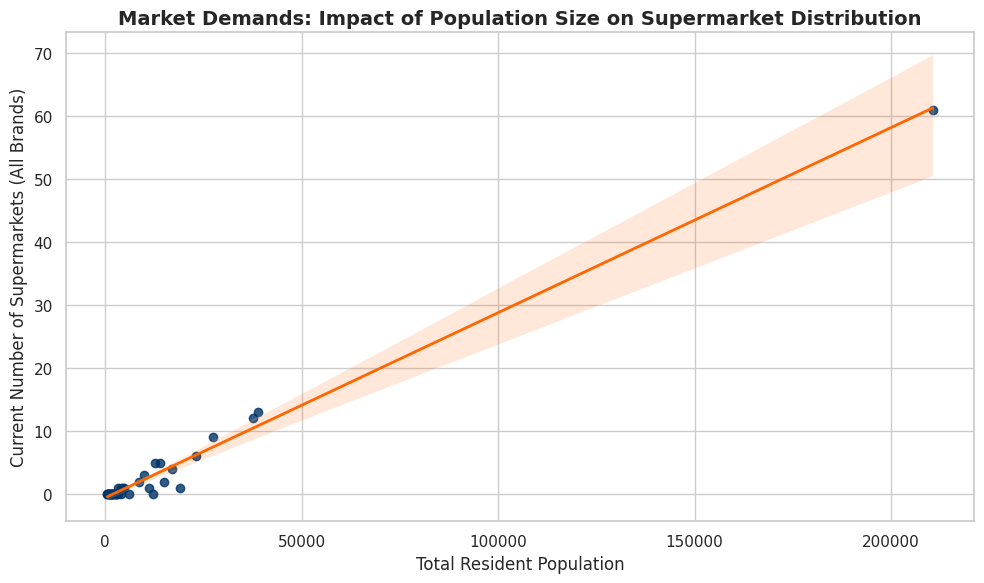

In [ ]:
# ==============================================================================
# STEP 6: DATA VISUALIZATION & PLOTTING
# ==============================================================================
print("\nStep 7: Plotting analytical graphs...")
# Create a regression relationship scatter plot
plt.figure(figsize=(10, 6))
sns.regplot(x='POPULATION', y='STORE_COUNT', data=df_model, color='#003366', line_kws={'color':'#FF6600', 'lw':2})
plt.title('Market Demands: Impact of Population Size on Supermarket Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Total Resident Population', fontsize=12)
plt.ylabel('Current Number of Supermarkets (All Brands)', fontsize=12)
plt.tight_layout()
plt.savefig('Geneva_Market_Regression_Plot.png', dpi=300)
plt.show()

In [ ]:
# ==============================================================================
# STEP 7: INTERACTIVE GEOSPATIAL MAP GENERATION
# ==============================================================================
print("Step 8: Constructing interactive geospatial choropleth map...")
# Initialize a clear canvas centered at Geneva's geographic midpoint
center_lat = geneva_boundaries.geometry.centroid.y.mean()
center_lon = geneva_boundaries.geometry.centroid.x.mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=11.5, tiles="cartodbpositron")

# Construct the colored choropleth layer based on the calculated Opportunity Score
choropleth = folium.Choropleth(
    geo_data=df_model,
    name="Market Expansion Opportunities",
    data=df_model,
    columns=["COMMUNE_NAME", "OPPORTUNITY_SCORE"],
    key_on="feature.properties.COMMUNE_NAME",
    fill_color="YlGnBu",  # Darker blue means more under-served / higher business opportunity
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Opportunity Score (Higher Value = Desirable Target Area)",
    nan_fill_color="white"
)

# Append detailed interactive tooltips to commune layers on hover
choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['COMMUNE_NAME', 'OPPORTUNITY_SCORE', 'STORE_COUNT', 'POPULATION'],
        aliases=['Municipality:', 'Opportunity Score:', 'Existing Stores:', 'Population Count:'],
        localize=True
    )
)
choropleth.add_to(m)

# Overlay exact pins for Migros and competitor stores to see localized proximity
for idx, row in joined_stores.iterrows():
    marker_color = 'red' if row['brand_category'] == 'Coop' else 'orange' if row['brand_category'] == 'Migros' else 'blue'

    popup_card = f"""
    <div style='font-family: Arial, sans-serif; width: 200px;'>
        <h4 style='margin:0 0 5px 0; color:#333;'>{row['brand_category']}</h4>
        <b>Shop Type:</b> {row['shop']}<br>
        <b>Address:</b> {row.get('addr:street', 'N/A')} {row.get('addr:housenumber', '')}<br>
        <b>Municipality:</b> {row['COMMUNE_NAME']}
    </div>
    """
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3.5,
        popup=folium.Popup(popup_card, max_width=250),
        color=marker_color,
        fill=True,
        fill_opacity=0.9
    ).add_to(m)

# Save the map as a dynamic HTML file
m.save('Migros_Geneva_Opportunity_Map.html')
print("✅ Project Execution Finished! Open 'Migros_Geneva_Opportunity_Map.html' to interact with your data.")

# Display inside Jupyter cell
m

Step 8: Constructing interactive geospatial choropleth map...


/tmp/ipykernel_2199/561670831.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lat = geneva_boundaries.geometry.centroid.y.mean()
/tmp/ipykernel_2199/561670831.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  center_lon = geneva_boundaries.geometry.centroid.x.mean()


✅ Project Execution Finished! Open 'Migros_Geneva_Opportunity_Map.html' to interact with your data.
